# Financial Services in Tanzania

## The training dataset contains demographic information and what financial services are used by approximately 10,000 individuals across Tanzania. This data was extracted from the FSDT Finscope 2017 survey and prepared specifically for this challenge.

## This dataset is the geospatial mapping of all cash outlets in Tanzania in 2012. Cash outlets in this case included commercial banks, community banks, ATMs, microfinance institutions, mobile money agents, bus stations and post offices. This data was collected by FSDT.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np

In [2]:
financial_services = pd.read_csv('datasets/training.csv')

In [3]:
financial_services.head(2)

,ID,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8_1,Q8_2,...,Q17,Q18,Q19,Latitude,Longitude,mobile_money,savings,borrowing,insurance,mobile_money_classification
0,5086,98,2,3,1,1,2,2,0,0,...,-1,4,4,-4.460442,29.811396,0,0,0,0,0
1,1258,40,1,1,3,5,1,1,1,0,...,4,1,4,-6.176438,39.244871,1,1,1,0,3


We should rename the columns for readability.

In [4]:
financial_services.rename({'Q1': 'age', 'Q2': 'gender','Q3':'marital_status', 
                           'Q4':'highest_education','Q5':'land_ownership', 
                           'Q6':'personally_owned','Q7':'own_mobile',
                           'Q8_1': "Salaries", 'Q8_2': "Trading", 
                           'Q8_3': "Service",'Q8_4': "Piece Work",
                           'Q8_5': "Rental", 'Q8_6': "Interest", 
                           'Q8_7': "Pension", 'Q8_8': "Welfare",
                           'Q8_9': "Reliance", 'Q8_10': "No Income", 'Q8_11': "Other",
                           'Q9':'employer_for_salary', 'Q10':'items_sold',
                           'Q11':'type_of_service', 'Q12':'money_sent_past_12_months',
                           'Q13':'money_last_sent','Q14':'money_received_past_12_months',
                           'Q15':'money_last_received','Q16':'mobilemoney_frequency_past_12_months',
                           'Q17':'pay_bills_using_mobilemoney_past_12_months','Q18':'kiswhahili_literacy',
                           'Q19':'english_literacy'}, axis=1, inplace=True)

### Examine the dataset. Are there any missing observations or columns where the data do not seem valid?

We need to look within are dataset to see if there are any null values.

In [5]:
print(f'There are {financial_services.isnull().sum().sum()} null values')

There are 0 null values


We also need to look for invalid data

In [6]:
data_dict = {'gender':[1,2], 'marital_status': [1,4], 
             'highest_education': [1,7], 'land_ownership': [1,6],
             'personally_owned': [1,2],'own_mobile': [1,2],      
             'Salaries': [0,1], 'Trading': [0,1],
             'Service': [0,1],'Piece Work': [0,1], 
             'Rental': [0,1],'Interest': [0,1],  
             'Pension': [0,1], 'Welfare': [0,1],
             'Reliance': [0,1],'No Income': [0,1],
             'Other': [0,1], 
             'employer_for_salary':[-1,7],
             'items_sold':[-1,10], 'type_of_service': [-1,12],
             'money_sent_past_12_months': [1,2],'money_last_sent': [-1,6], 
             'money_received_past_12_months': [1,2], 'money_last_received': [-1,6], 
             'mobilemoney_frequency_past_12_months': [-1,5], 'pay_bills_using_mobilemoney_past_12_months': [-1,5],
             'kiswhahili_literacy': [1,5], 'english_literacy': [1,5],
             'mobile_money': [0,1],'savings': [0,1],
             'borrowing': [0,1],'insurance': [0,1], 
             'mobile_money_classification': [0,3] }


non_zero_columns = ['employer_for_salary', 'items_sold', 'type_of_service',
                        'money_last_sent', 'money_last_received', 'mobilemoney_frequency_past_12_months',
                        'pay_bills_using_mobilemoney_past_12_months']

for key in data_dict:
    if key in non_zero_columns:
        if 0 in financial_services[key].values:
            print(f'0 is an invalid value in {key}')   
            
    for value in financial_services[key].values:
        if (value > data_dict[key][-1]) or (value < data_dict[key][0]):
            print(f'value {value} in column \'{key}\' is invalid')

            indexNames = financial_services[financial_services[f'{key}'] == value].index
financial_services.drop(indexNames , inplace=True)
print(f'row at index {indexNames} removed.')


value 8 in column 'highest_education' is invalid
value 8 in column 'highest_education' is invalid
row at index Int64Index([1053, 2486], dtype='int64') removed.


### Get basic descriptive statistics for the dataset.

There are two types of variables which are categorical and continuous, separate statistics are needed.

Continuous variables:

In [7]:
financial_services[['age', 'Latitude', 'Longitude']].describe()

,age,Latitude,Longitude
count,7092.000000,7092.000000,7092.000000
mean,38.230541,-6.035482,35.354899
std,16.325729,2.720469,2.899436
min,16.000000,-11.467463,29.639578
25%,25.000000,-8.279598,32.935719
50%,35.000000,-6.088322,35.073388
75%,48.000000,-3.517604,38.352004
max,100.000000,-1.084000,40.258744


The average age in Tanzania is 38 years, the minimum is 16 whereas the max is 100.
We have a total of 7092 records.

Categorical variables:

In [8]:
category = financial_services[["gender", "marital_status", "highest_education", 
                    "land_ownership", "personally_owned", "own_mobile",
                    "Salaries", "Trading", "Service","Piece Work",
                    "Rental", "Interest", "Pension", "Welfare",
                    "Reliance", "No Income", "Other", 
                    'employer_for_salary', 'items_sold', 
                    'type_of_service', 'money_sent_past_12_months',
                    'money_last_sent','money_received_past_12_months',
                    'money_last_received','mobilemoney_frequency_past_12_months',
                    'pay_bills_using_mobilemoney_past_12_months','kiswhahili_literacy',
                    'english_literacy','mobile_money', 'savings',
                    'borrowing', 'insurance', 'mobile_money_classification']].astype("category")

category.describe(include='all')

,gender,marital_status,highest_education,land_ownership,personally_owned,own_mobile,Salaries,Trading,Service,Piece Work,...,money_last_received,mobilemoney_frequency_past_12_months,pay_bills_using_mobilemoney_past_12_months,kiswhahili_literacy,english_literacy,mobile_money,savings,borrowing,insurance,mobile_money_classification
count,7092,7092,7092,7092,7092,7092,7092,7092,7092,7092,...,7092,7092,7092,7092,7092,7092,7092,7092,7092,7092
unique,2,4,7,6,2,2,2,2,2,2,...,7,5,6,5,5,2,2,2,2,4
top,2,1,3,1,2,1,0,1,0,0,...,-1,1,-1,1,4,1,0,0,0,3
freq,3972,4547,3446,3000,5961,4269,6651,4470,6680,4700,...,4417,5088,6024,4943,4686,3928,3819,4021,6020,3125


Majority within the dataset are females, married persons, that have their primary completed and also personally own the land.

### Each individual is classified into four mutually exclusive categories:

#### No_financial_services: Individuals who do not use mobile money, do not save, do not have credit, and do not have insurance
#### Other_only: Individuals who do not use mobile money, but do use at least one of the other financial services (savings, credit, insurance)  
#### Mm_only: Individuals who use mobile money only    
#### Mm_plus: Individuals who use mobile money and also use at least one of the other financial services (savings, credit, insurance)


### Create appropriate graphs to visually represent the relationship between financial services accessed (non-mobile, mobile, both) and age, gender, marital status, land ownership and type of income.

### financial services and age:

In [9]:
financial_services['age_range'] = pd.cut(financial_services['age'], bins=[0,20,40,60,80,100])
sns.set(style="whitegrid")

financial_services['mobile_money_classification'].replace( [0, 1, 2, 3], 
                  ['No_financial_services', 'financial_service_only', 'mobile_money_only', 'mobile_money_plus'],inplace=True)

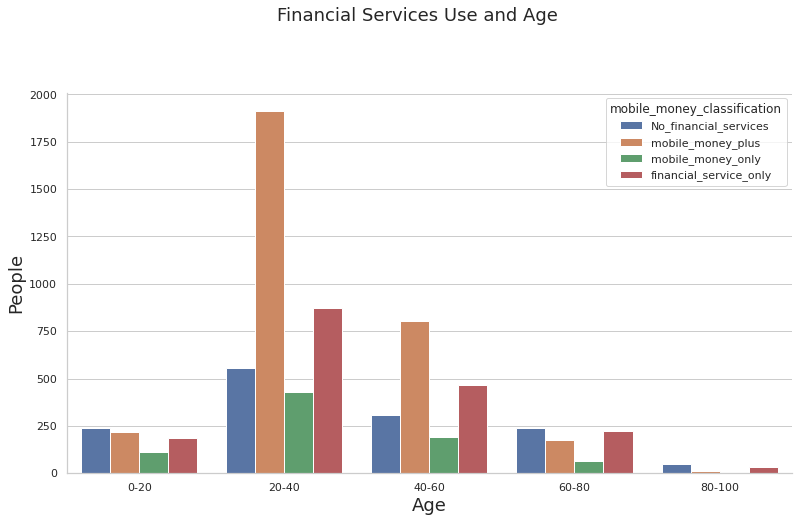

In [10]:
plt.figure(figsize = (13, 7))
plot = sns.countplot(x='age_range', data=financial_services, hue='mobile_money_classification')

plot.set_xlabel("Age", size=18)
plot.set_ylabel("People", size=18)
plt.suptitle("Financial Services Use and Age", va ='top', y=1.05, size=18)
sns.despine()
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xticks((np.arange(5)), ("0-20","20-40","40-60","60-80","80-100"))
plt.show()

By looking at this dataset it is evident that younger people in Tanzania within the ages 20-40 use the most financial services- with the age 30 being the highest- The older a person is in Tanzania is indirectly proportional to the number of financial services used, we can take into account that the health of a person contributes highly on the number of financial services used.

Age 16 to 19 doesn't have much users of mobile money services.

### financial services and gender:


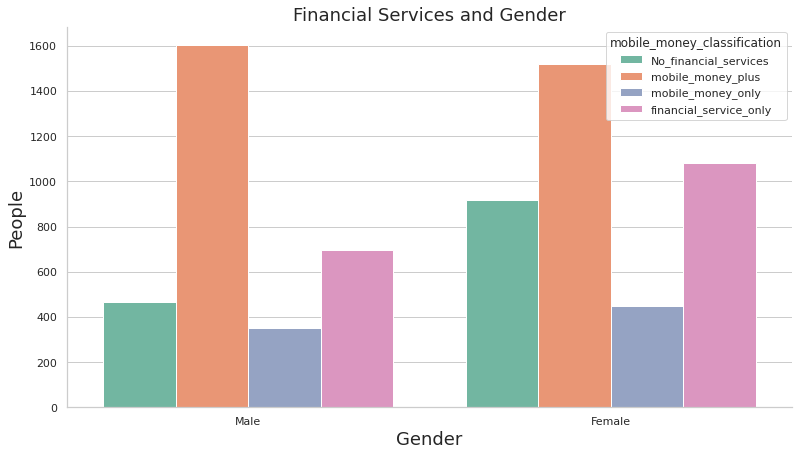

In [11]:
plt.figure(figsize = (13, 7))
sns.countplot(x='gender', hue='mobile_money_classification',
              data=financial_services, palette="Set2")
plt.xlabel("Gender", size=18)
plt.ylabel("People", size=18)
sns.despine()
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xticks((0, 1), ("Male", "Female"))
plt.title("Financial Services and Gender", size=18)
plt.legend(loc=1,title='mobile_money_classification')
plt.show()

More male figures in society use mobile money and financial services. Majority of females over males don't use financial services at all, more females use mobile money of men, however more females use at least one type of financial service over male figures.

### financial services and marital status:

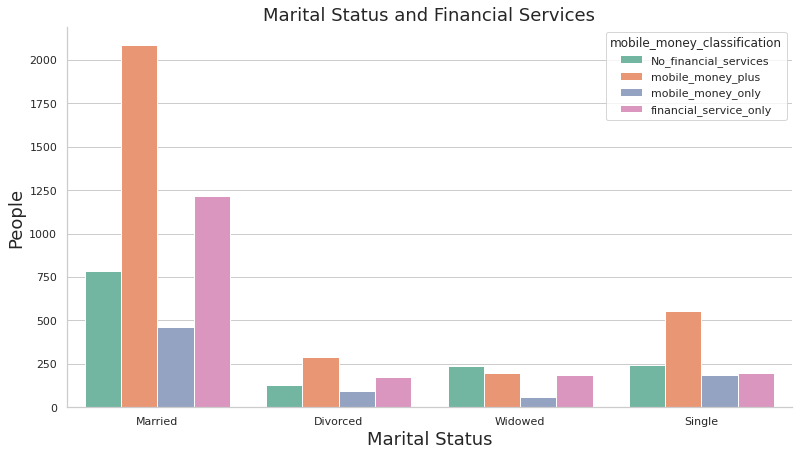

In [12]:
plt.figure(figsize = (13, 7))
sns.countplot(x='marital_status',data=financial_services, 
              hue='mobile_money_classification', palette="Set2")
plt.xlabel("Marital Status", size=18)
plt.ylabel("People", size=18)
sns.despine()
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xticks((0, 1, 2, 3), ("Married", "Divorced", "Widowed", "Single"))
plt.title("Marital Status and Financial Services", size=18)
plt.show()

Persons who are married have an extremely high chance of using mobile money and at least one financial services, compared to persons who are divorced, widowed and single.

The highest use of financial services is within marriage- 2000 of them use mobile money and at least one financial service, it is then followed by single people with slightly more than 500 using mobile money and a financial service- followed by divorced and lastly widowed.

### financial services and land ownership:

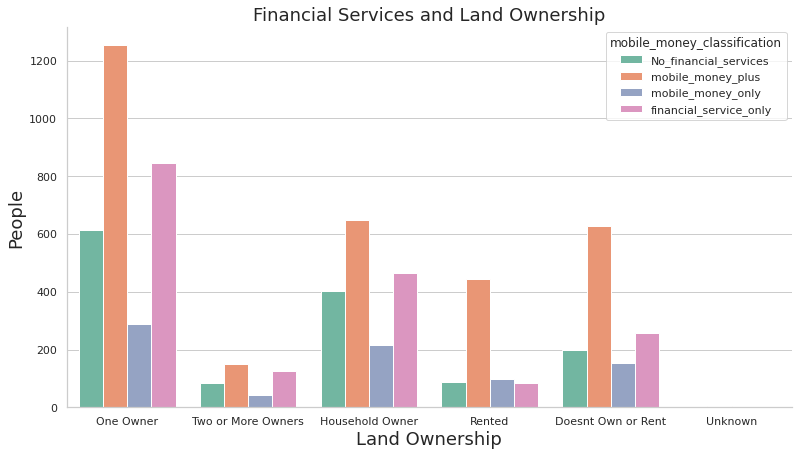

In [13]:
plt.figure(figsize = (13, 7))
sns.countplot(x='land_ownership',data=financial_services, hue='mobile_money_classification', palette="Set2")
plt.xlabel("Land Ownership", size=18)
plt.ylabel("People", size=18)
sns.despine()
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xticks((0, 1, 2, 3, 4, 5), 
           ("One Owner", "Two or More Owners", "Household Owner", "Rented", "Doesnt Own or Rent", "Unknown"))
plt.title("Financial Services and Land Ownership", size=18)
plt.show()

A single owner of land uses financial services the most. Followed by a household owner and then those that don't pay rent. It's less likely for a person to use a financial service if they don't own any land.

Most users of financial services own land/plot where they live, if you have a household member that owns the land you're more often than not to use mobile money. You won't be able to use financial service or mobile money if you don't know where you live in Tanzania, could this be because of lack of education or income?

Most people who rent use mobile money and at least one financial service. Almost everyone uses mobile mobile within different land ownerships. If you don’t own or rent the land you're still more likely to use mobile money.

If you own land, it's more likely that you'll use a financial service in Tanzania.

### financial services and income visualizations:
Going forward there are 11 sources of incomes used in the data set, we'll combine them into a single column to get our visualizations and the frequency of use.

Lets rename the income columns for readability.

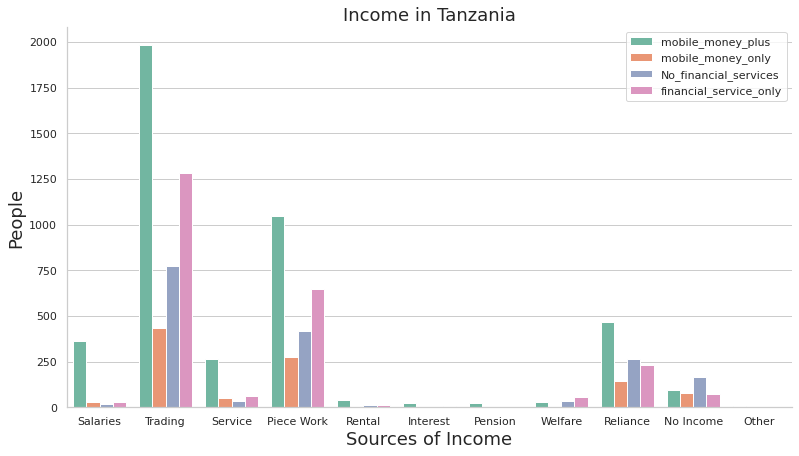

In [14]:
plt.figure(figsize = (13, 7))
income_and_financial_service = pd.melt(financial_services, id_vars = 'mobile_money_classification', 
                            value_vars=["Salaries", "Trading", "Service","Piece Work",
                           "Rental", "Interest", "Pension", "Welfare",
                           "Reliance", "No Income", "Other"])


types_of_income = income_and_financial_service[income_and_financial_service['value']== 1]
sns.countplot(x='variable', data=types_of_income, hue='mobile_money_classification', palette="Set2")
sns.despine()
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.xlabel("Sources of Income", size=18)
plt.ylabel("People", size=18)
plt.title("Income in Tanzania", size=18)
plt.legend(loc=1)
plt.show()

Trading seems to be the more prominent source of income, followed by Piece Work. Very few make money through interest and pension. With the main sources being trading and piece work, one can begin to see why majority of older people don't use mobile money, pension is really scarce.

People in Tanzania also rely on 'handouts' or relying on a second person for money. Is it safe to consider Tanzania as not a very economically prosperous country? Majority of persons use mobile money in the different sources of income, excluding where people don't have an income as well as welfare.

## Create appropriate graphs to visually represent the relationship between how often mobile money are used and age, gender, marital status, land ownership and type of income.

### frequency of mobile money and age:

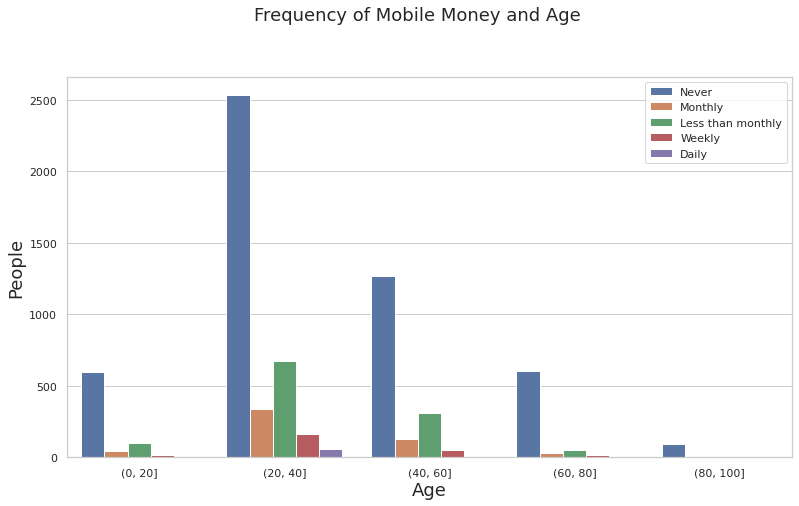

In [15]:
plt.figure(figsize = (13, 7))
financial_services['mobilemoney_frequency_past_12_months'].replace(
    [-1, 1, 2, 3, 4, 5],
    ['not applicable','Never', 'Daily', 'Weekly', 'Monthly',"Less than monthly"],inplace=True)

plot = sns.countplot(x='age_range', data=financial_services, hue='mobilemoney_frequency_past_12_months')
plt.suptitle('Frequency of Mobile Money and Age', va ='top', y=1.02, size=18)
plot.set_xlabel("Age", size=18)
plot.set_ylabel("People", size=18)
plt.legend(loc=1)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.show()

It's evident that the use of mobile money is rare in Tanzania. Especially ages 20-40 where they've never used a mobile money. Seems people commonly use mobile money less than monthly.

### frequency of mobile money and gender:

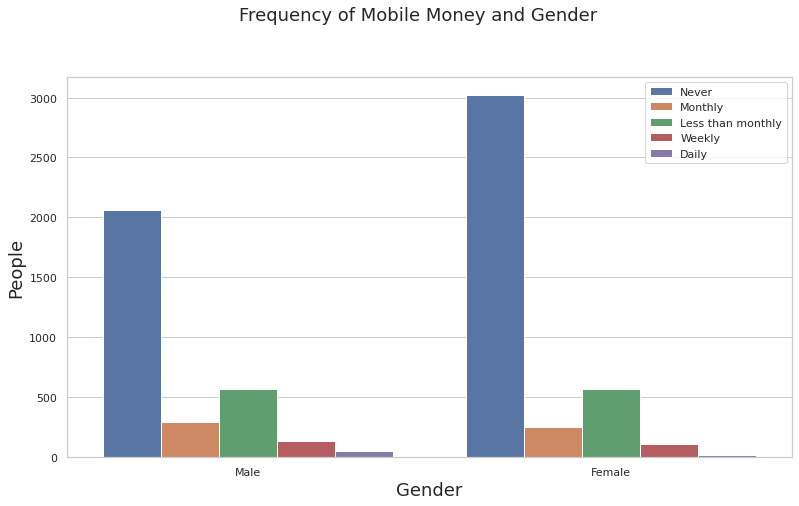

In [16]:
plt.figure(figsize = (13, 7))
plot = sns.countplot(x='gender', data=financial_services, hue='mobilemoney_frequency_past_12_months')
plot.set_xlabel("Gender", size=18)
plot.set_ylabel("People", size=18)
plt.legend(loc=1)
plt.suptitle('Frequency of Mobile Money and Gender', va ='top', y=1.02, size=18)
plt.xticks((0, 1), ("Male", "Female"))
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.show()

Most females have never used mobile money than men. With both genders using mobile money less than monthly.

### frequency of mobile money and marital status:

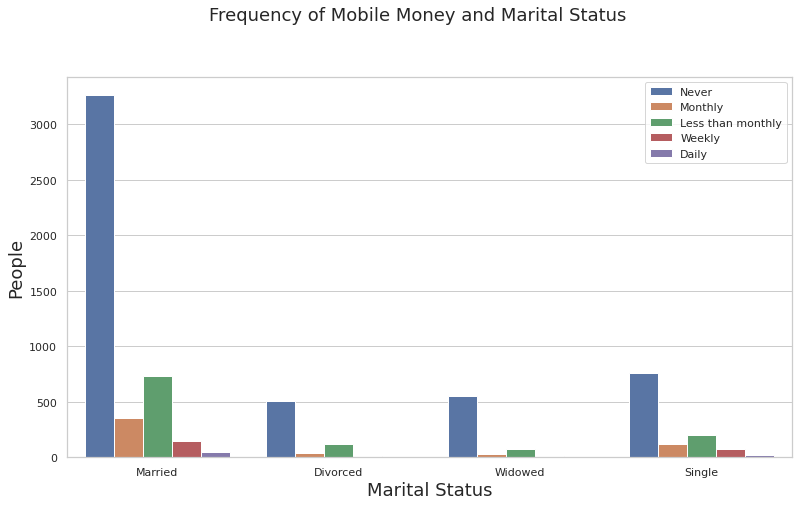

In [17]:
plt.figure(figsize = (13, 7))
plot = sns.countplot(x='marital_status', data=financial_services, hue='mobilemoney_frequency_past_12_months')
plt.xticks((0, 1, 2, 3), ("Married", "Divorced", "Widowed", "Single"))
plot.set_xlabel("Marital Status", size=18)
plot.set_ylabel("People", size=18)
plt.legend(loc=1)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.suptitle('Frequency of Mobile Money and Marital Status', va ='top', y=1.02, size=18)
plt.show()

Mobile money is mostly used by married people.

### frequency of mobile money and income:

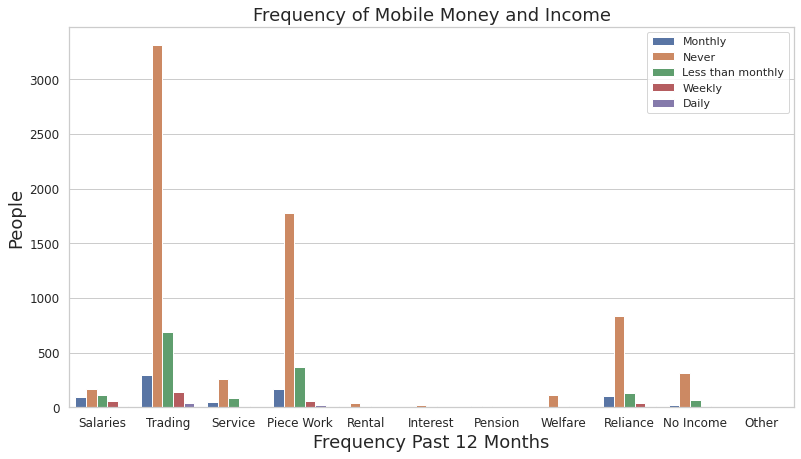

In [18]:
plt.figure(figsize = (13,7))
income_and_financial_service = pd.melt(financial_services, id_vars = 'mobilemoney_frequency_past_12_months', 
                            value_vars=["Salaries", "Trading", "Service","Piece Work",
                           "Rental", "Interest", "Pension", "Welfare",
                           "Reliance", "No Income", "Other"])

income_and_financial_service = income_and_financial_service[income_and_financial_service['value'] == 1]

plot = sns.countplot(x="variable", hue="mobilemoney_frequency_past_12_months", data=income_and_financial_service)
plot.set_xlabel("Frequency Past 12 Months", size=18)
plot.set_ylabel("People", size=18) 
plt.yticks(size=12)
plt.xticks(size=12)
plt.legend(loc=1)
plt.title('Frequency of Mobile Money and Income',size=18)
plt.show()

Among those that trade, majority have never used a mobile money. Majority of the other sources of income have never used a mobile money as well.

## Create a map to visually explore geographic distribution of mobile money coverage with respect to type of income.

In [19]:
financial_service_geo = gpd.GeoDataFrame(financial_services, geometry = 
                                        gpd.points_from_xy(financial_services.Longitude, financial_services.Latitude))

In [20]:
world_data = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

In [21]:
income_map = pd.melt(financial_service_geo, id_vars=['geometry'],
                           value_vars=[
                                        "Salaries",
                                        "Trading",
                                        "Service",
                                        "Piece Work",
                                        "Rental",
                                        "Interest",
                                        "Pension",
                                        "Welfare",
                                        "Reliance",
                                        "No Income",
                                        "Other"], 
                                       var_name='income')

geo_income_filter = income_map[income_map['value'] == 1]

### income map:

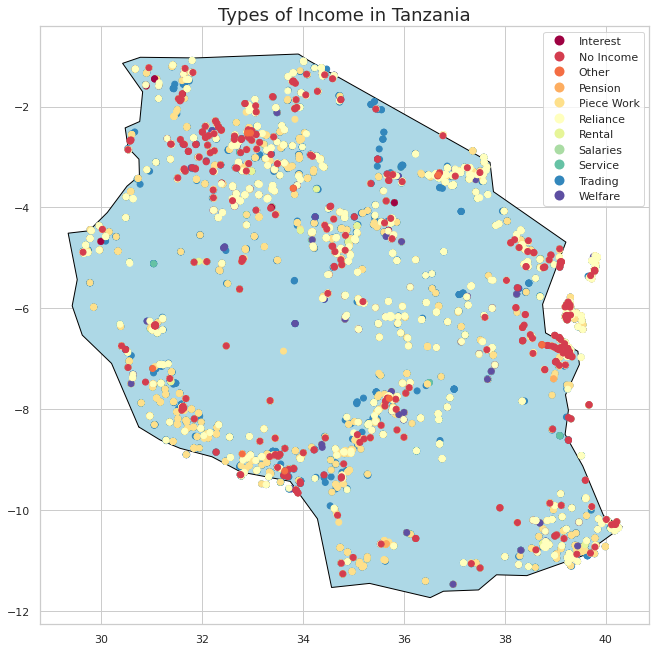

In [22]:
axis = world_data[world_data.name == 'Tanzania'].plot(color = 'lightblue'
                                                        , edgecolor='black')

geo_income_filter.plot(column= 'income', categorical=True, cmap='Spectral',
                           ax = axis, legend=True)
plt.title('Types of Income in Tanzania', size=18)
fig = plt.gcf()
fig.set_size_inches(15, 11)
plt.tick_params(axis='both', which='minor', labelsize=12)
plt.show()

Majority of people in Tanzania rely on 'handouts' or rather rely on other people to survive. Also after those that rely on others for money, majority of other people don't have an income.

We can conclude that families that consist of marriage, owning a piece of land and income obtained through selling seem to use a lot more financial services, we can also expect those families to have higher incomes. Financial services are commonly used by people of range 16 - 50, health decreases as you get older that's why the use of financial services decreases. We can also see that out of the top earners in Tanzania, almost everyone of them don't use financial services daily.